In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

In [ ]:
# Load dataset
df = pd.read_csv("Training/ranked_responses_final.csv")

Number of Times Each Model Was Ranked #1:

deepseek/deepseek-chat: 2164
anthropic/claude-3.5-sonnet: 2025
openai/gpt-4o: 977
perplexity/sonar: 609


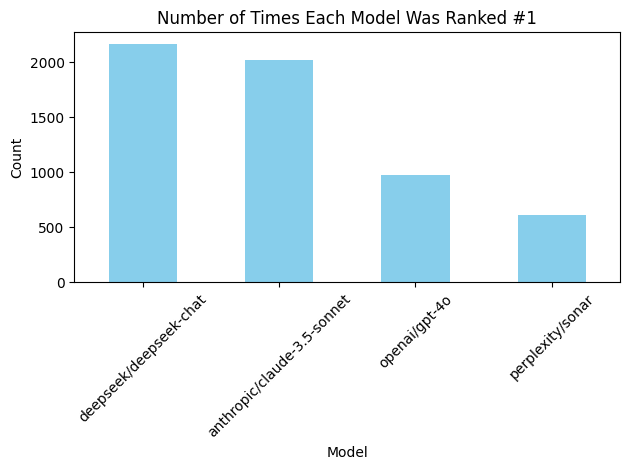

In [ ]:
# Count how many times each model was ranked 1
rank_1_counts = df[df["Rank"] == 1]["Model"].value_counts()

# Display
print("Number of Times Each Model Was Ranked #1:\n")
for model, count in rank_1_counts.items():
    print(f"{model}: {count}")

rank_1_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Times Each Model Was Ranked #1")
plt.ylabel("Count")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

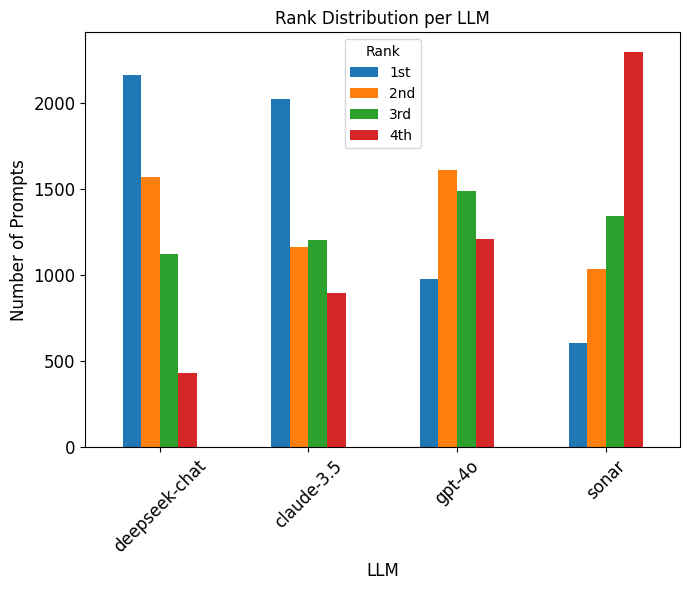

In [ ]:
# Count how many times each model got each rank
rank_counts = df.groupby(["Model", "Rank"]).size().unstack(fill_value=0).sort_index()

# Optional: sort models by how often they were ranked #1
rank_counts = rank_counts.sort_values(by=1, ascending=False)

# Plot grouped bar chart
rank_counts.plot(kind='bar', figsize=(7, 6))
plt.title("Rank Distribution per LLM")
plt.ylabel("Number of Prompts", fontsize=12)
plt.xlabel("LLM", fontsize=12)
plt.xticks(rotation=45, fontsize=12)  # Increase x-axis tick label font size
plt.yticks(fontsize=12)               # Increase y-axis tick label font size
plt.legend(title="Rank", labels=["1st", "2nd", "3rd", "4th"])
plt.tight_layout()


plt.show()


Rank Distribution for Summaries:

Rank             1    2    3    4
Model                            
deepseek-chat  627  285  127   50
sonar          220  203  255  411
claude-3.5     204  313  309  263
gpt-4o         159  315  385  230


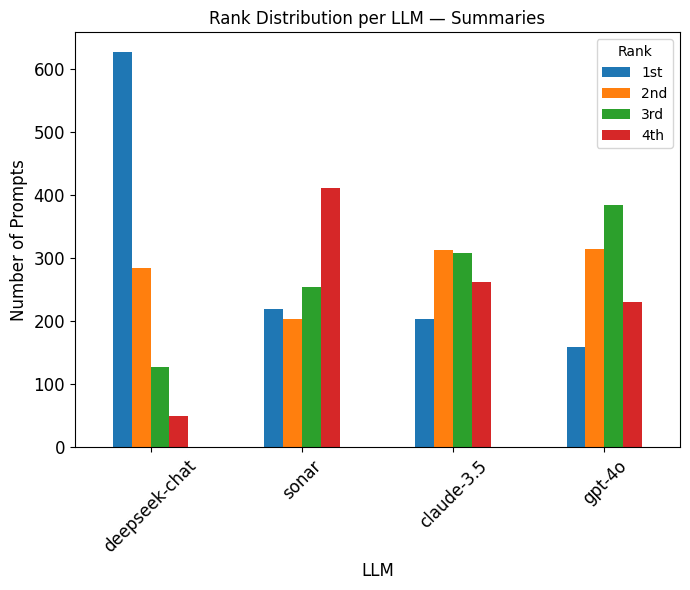


Rank Distribution for English:

Rank             1    2    3    4
Model                            
deepseek-chat  420  281  227   50
claude-3.5     306  196  286  190
gpt-4o         273  364  193  148
sonar           70  130  261  517


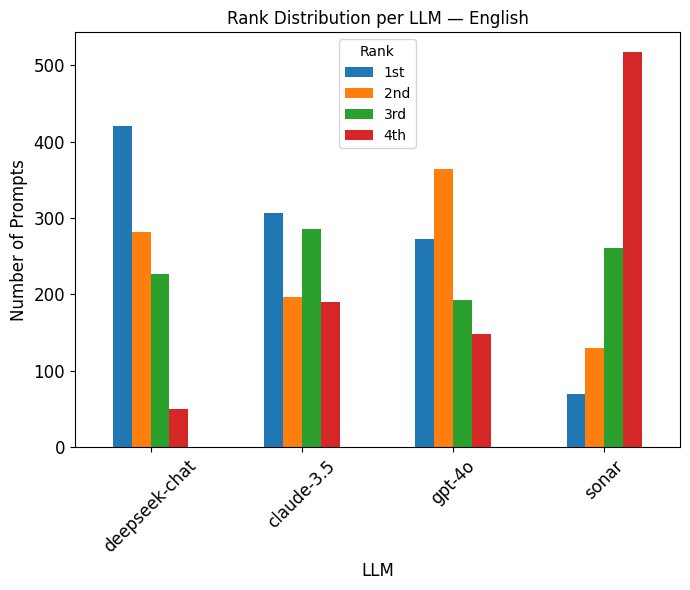


Rank Distribution for Math:

Rank             1    2    3    4
Model                            
deepseek-chat  388  300  229   62
claude-3.5     346  250  235  148
gpt-4o         282  272  210  215
sonar           69  169  246  495


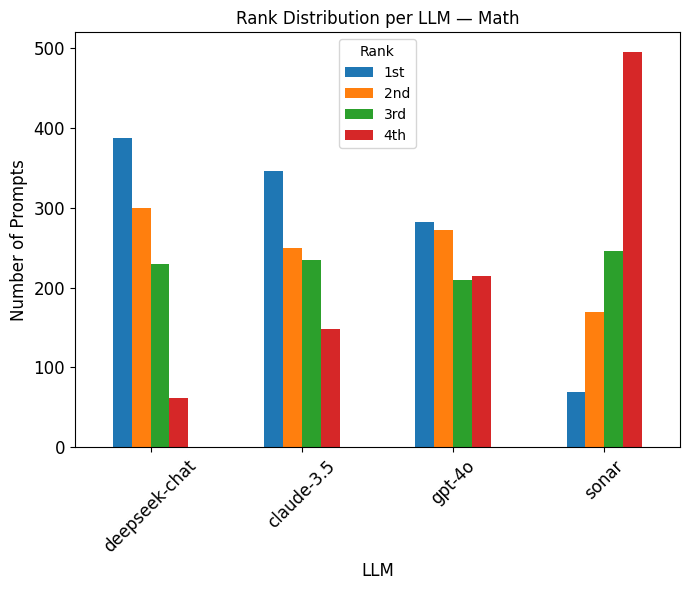


Rank Distribution for Coding:

Rank              1    2    3    4
Model                             
claude-3.5     1043  195   81   43
deepseek-chat   169  475  477  241
gpt-4o          168  464  414  316
sonar            73  272  360  657


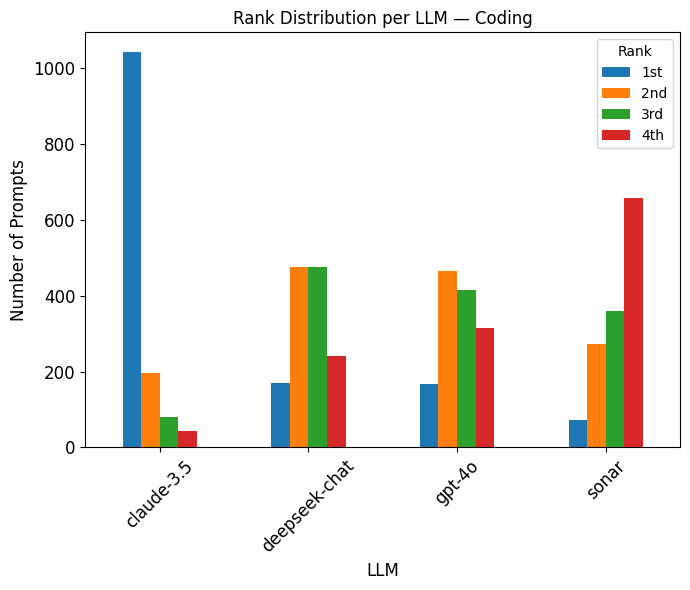


Rank Distribution for Reasoning:

Rank             1    2    3    4
Model                            
deepseek-chat  560  228   64   29
sonar          177  263  223  218
claude-3.5     126  209  292  254
gpt-4o          95  199  286  301


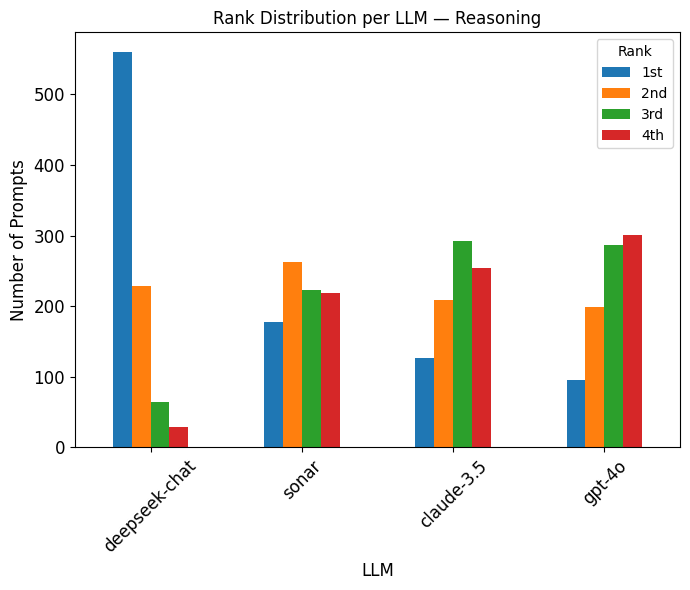

In [5]:
# Mapping for shortening model names
model_mapping = {
    'deepseek/deepseek-chat': 'deepseek-chat',
    'perplexity/sonar': 'sonar',
    'anthropic/claude-3.5-sonnet': 'claude-3.5',
    'openai/gpt-4o': 'gpt-4o'
}

# Replace the model names in the DataFrame
df["Model"] = df["Model"].replace(model_mapping)

# Your category mapping
category_map = {
    'Summaries': ['summaries'],
    'English': ['english_1', 'english_2'],
    'Math': ['math_1', 'math_2'],
    'Coding': ['coding_1', 'coding_2', 'coding_3'],
    'Reasoning': ['reasoning_1', 'reasoning_2', 'reasoning_3']
}

# Reverse the mapping: source → category
source_to_category = {src: cat for cat, sources in category_map.items() for src in sources}

# Create a new "Category" column in df
df["Category"] = df["Source"].map(source_to_category)

# Filter out any rows that didn’t match a category
df_category = df.dropna(subset=["Category"])

# Plot per category
for category in category_map:
    subset = df_category[df_category["Category"] == category]

    # Group by model and rank, count occurrences
    rank_counts = subset.groupby(["Model", "Rank"]).size().unstack(fill_value=0).sort_index()

    # Sort by number of rank 1s for clarity
    rank_counts = rank_counts.sort_values(by=1, ascending=False)

    # Print numeric values
    print(f"\nRank Distribution for {category}:\n")
    print(rank_counts)

    # Plot grouped bar chart
    rank_counts.plot(kind='bar', figsize=(7, 6))
    plt.title(f"Rank Distribution per LLM — {category}", fontsize=12)
    plt.ylabel("Number of Prompts", fontsize=12)
    plt.xlabel("LLM", fontsize=12)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title="Rank", labels=["1st", "2nd", "3rd", "4th"])
    plt.tight_layout()
    
    # Optional: save each plot as a PDF file
    
    plt.show()
